## 확률적 자료구조를 이용한 온라인 리테일 스트림 데이터의 실시간 근사 분석

### 0. 요약 (Abstract)
본 과제는 대용량 커머스 트래픽 환경에서 메모리 효율성을 극대화하기 위해 네 가지 핵심 스트리밍 알고리즘(Bloom Filter, Count-Min Sketch, HyperLogLog, Reservoir Sampling)을 구현하고 성능을 분석한다. 실제 영국 온라인 리테일 데이터를 활용하여 각 알고리즘의 추정 정확도와 자원 소모량 사이의 트레이드오프를 고찰하며, 실무 시스템 설계 시 최적의 파라미터 선정 가이드라인을 제시한다.

### STEP 01. 데이터 준비 및 구조 파악

In [1]:
import pandas as pd
import time
import sys
import hashlib
import math
import random

FILE_PATH = 'Online Retail.xlsx' 

def get_data_stream(path, limit=100000):
    """Excel 데이터를 읽어 한 줄씩 사전(Dict) 형태로 반환"""
    # 엑셀 파일 로드
    df = pd.read_excel(path, engine='openpyxl')
    
    # NaN(결측치) 처리: CustomerID가 없는 데이터는 분석에서 제외
    df = df.dropna(subset=['CustomerID'])
    
    for i, row in df.iterrows():
        if i >= limit: break
        # 각 행을 dictionary 형태로 변환하여 반환
        yield row.to_dict()

# 데이터 구조 샘플 확인
try:
    sample_stream = get_data_stream(FILE_PATH)
    sample = next(sample_stream)
    print(f"데이터 샘플 구조: {sample.keys()}")
except FileNotFoundError:
    print("파일을 찾을 수 없습니다.")

데이터 샘플 구조: dict_keys(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'])


### 01.1 데이터 실제 구조 및 확인

In [2]:
def inspect_online_retail(path, n=5):
    print(f"[{path} 내부 데이터 샘플 확인]")
    print("-" * 60)
    
    # 데이터 로드
    df = pd.read_excel(path, engine='openpyxl', nrows=n)
    
    # 변수 테이블 정보에 기반한 한글 매핑
    field_map = {
        'InvoiceNo': '거래 번호 (ID)',
        'StockCode': '상품 코드 (ID)',
        'Description': '상품명 (Feature)',
        'Quantity': '수량 (Integer)',
        'InvoiceDate': '거래 일시 (Date)',
        'UnitPrice': '단가 (Continuous)',
        'CustomerID': '고객 ID (Categorical)',
        'Country': '국가 (Categorical)'
    }
    
    for i, row in df.iterrows():
        print(f"Record {i+1}:")
        for col, kor_name in field_map.items():
            value = row.get(col, 'N/A')
            print(f"  - {kor_name}: {value}")
        print("-" * 60)

# 실행
inspect_online_retail(FILE_PATH)

[Online Retail.xlsx 내부 데이터 샘플 확인]
------------------------------------------------------------
Record 1:
  - 거래 번호 (ID): 536365
  - 상품 코드 (ID): 85123A
  - 상품명 (Feature): WHITE HANGING HEART T-LIGHT HOLDER
  - 수량 (Integer): 6
  - 거래 일시 (Date): 2010-12-01 08:26:00
  - 단가 (Continuous): 2.55
  - 고객 ID (Categorical): 17850
  - 국가 (Categorical): United Kingdom
------------------------------------------------------------
Record 2:
  - 거래 번호 (ID): 536365
  - 상품 코드 (ID): 71053
  - 상품명 (Feature): WHITE METAL LANTERN
  - 수량 (Integer): 6
  - 거래 일시 (Date): 2010-12-01 08:26:00
  - 단가 (Continuous): 3.39
  - 고객 ID (Categorical): 17850
  - 국가 (Categorical): United Kingdom
------------------------------------------------------------
Record 3:
  - 거래 번호 (ID): 536365
  - 상품 코드 (ID): 84406B
  - 상품명 (Feature): CREAM CUPID HEARTS COAT HANGER
  - 수량 (Integer): 8
  - 거래 일시 (Date): 2010-12-01 08:26:00
  - 단가 (Continuous): 2.75
  - 고객 ID (Categorical): 17850
  - 국가 (Categorical): United Kingdom
-----------------

### STEP 02. 알고리즘 구현

> Bloom Filter, Count-Min Sketch, HyperLogLog, Reservoir Sampling 이 4종의 알고리즘을 구현하여 비교한다.

In [3]:
class StreamingAlgorithms:
    def __init__(self):
        # (1) Bloom Filter (m=1M, k=5)
        self.bf_m = 1000000; self.bf_k = 5
        self.bf_bit_array = [0] * self.bf_m
        
        # (2) Count-Min Sketch (w=2000, d=5)
        self.cms_w = 2000; self.cms_d = 5
        self.cms_table = [[0] * self.cms_w for _ in range(self.cms_d)]
        
        # (3) HyperLogLog (b=10)
        self.hll_b = 10; self.hll_m = 1 << self.hll_b
        self.hll_registers = [0] * self.hll_m
        
        # (4) Reservoir Sampling (k=1000)
        self.res_k = 1000; self.res_sample = []; self.res_count = 0

    # --- Bloom Filter ---
    def bf_add(self, item):
        for i in range(self.bf_k):
            # item을 명시적으로 문자열로 변환
            idx = int(hashlib.md5((str(item) + str(i)).encode()).hexdigest(), 16) % self.bf_m
            self.bf_bit_array[idx] = 1
    def bf_query(self, item):
        for i in range(self.bf_k):
            idx = int(hashlib.md5((str(item) + str(i)).encode()).hexdigest(), 16) % self.bf_m
            if self.bf_bit_array[idx] == 0: return False
        return True

    # --- Count-Min Sketch ---
    def cms_add(self, item):
        for i in range(self.cms_d):
            idx = int(hashlib.sha1((str(item) + str(i)).encode()).hexdigest(), 16) % self.cms_w
            self.cms_table[i][idx] += 1
    def cms_estimate(self, item):
        return min(self.cms_table[i][int(hashlib.sha1((str(item) + str(i)).encode()).hexdigest(), 16) % self.cms_w] 
                    for i in range(self.cms_d))

    # --- HyperLogLog ---
    def hll_add(self, item):
        h = int(hashlib.sha256(str(item).encode()).hexdigest(), 16)
        idx = h & (self.hll_m - 1); w = h >> self.hll_b
        rho = (bin(w).split('1')[-1].count('0') + 1) if w > 0 else 32
        self.hll_registers[idx] = max(self.hll_registers[idx], rho)
    
    def hll_count(self):
        # Cardinality Estimation Formula 적용
        alpha = 0.7213 / (1 + 1.079 / self.hll_m)
        est = alpha * (self.hll_m**2) * (sum(2.0**-r for r in self.hll_registers)**-1)
        return int(est)

    # --- Reservoir Sampling ---
    def res_add(self, item):
        self.res_count += 1
        if len(self.res_sample) < self.res_k: self.res_sample.append(item)
        else:
            r = random.randint(0, self.res_count - 1)
            if r < self.res_k: self.res_sample[r] = item

### STEP 03. Ground Truth 계산

In [4]:
algo = StreamingAlgorithms()
# Ground Truth 자료구조
gt_customers = set(); gt_products = {}; gt_unique_users = set(); gt_full_data = []

start_time = time.time()
LIMIT = 100000

print("스트리밍 분석 및 Ground Truth 계산 중...")
for row in get_data_stream(FILE_PATH, limit=LIMIT):
    cust_id = row.get('CustomerID', 'Unknown')
    stock_code = row.get('StockCode', 'Unknown')
    
    # 알고리즘 업데이트
    algo.bf_add(cust_id); algo.cms_add(stock_code); algo.hll_add(cust_id); algo.res_add(row)
    
    # Ground Truth 업데이트
    gt_customers.add(cust_id); gt_products[stock_code] = gt_products.get(stock_code, 0) + 1
    gt_unique_users.add(cust_id); gt_full_data.append(row)

end_time = time.time()
print(f"완료, 처리 시간: {end_time - start_time:.4f}초")

스트리밍 분석 및 Ground Truth 계산 중...
완료, 처리 시간: 16.6187초


### STEP 04. 성능 분석 및 시각화 출력

#### 04.1 실험 결과 

In [5]:
print("\n" + "="*40)
print("            [실험 결과 종합 분석]")
print("="*40)

# (1) Bloom Filter 정확도 (False Positive 측정)
fp = sum(1 for i in range(1000) if algo.bf_query(f"fake_user_{i}"))
print(f"1. Bloom Filter FPR: {fp/10:.2f}%")

# (2) CMS 정확도 (상위 10개 상품 MAE)
sample_prods = list(gt_products.keys())[:100]
mae = sum(abs(algo.cms_estimate(p) - gt_products[p]) for p in sample_prods) / 100
print(f"2. CMS 빈도 추정 평균 오차(MAE): {mae:.2f}")

# (3) HLL 정확도 (고유 유저 수 오차율)
hll_est = algo.hll_count(); gt_count = len(gt_unique_users)
print(f"3. HLL 고유 유저 추정: {hll_est:,} (실제: {gt_count:,}, 오차율: {abs(hll_est-gt_count)/gt_count*100:.2f}%)")

# (4) Reservoir Sampling 분포 확인
print(f"4. Reservoir 샘플링 개수: {len(algo.res_sample)} (전체 {algo.res_count:,} 중 선택)")

# (5) 메모리 사용량 (근사치)
mem_stream = (sys.getsizeof(algo.bf_bit_array) + sys.getsizeof(algo.cms_table) + sys.getsizeof(algo.hll_registers)) / 1024
mem_gt = (sys.getsizeof(gt_customers) + sys.getsizeof(gt_products) + sys.getsizeof(gt_unique_users)) / 1024
print(f"\n[메모리] 알고리즘: {mem_stream:.2f} KB vs Ground Truth: {mem_gt:.2f} KB")
print(f"효율성: 약 {mem_gt/mem_stream:.1f}배 메모리 절감")


            [실험 결과 종합 분석]
1. Bloom Filter FPR: 0.00%
2. CMS 빈도 추정 평균 오차(MAE): 1.20
3. HLL 고유 유저 추정: 1,820 (실제: 1,664, 오차율: 9.38%)
4. Reservoir 샘플링 개수: 1000 (전체 65,085 중 선택)

[메모리] 알고리즘: 7820.73 KB vs Ground Truth: 400.51 KB
효율성: 약 0.1배 메모리 절감


#### 04.2 실험 결과 시각화

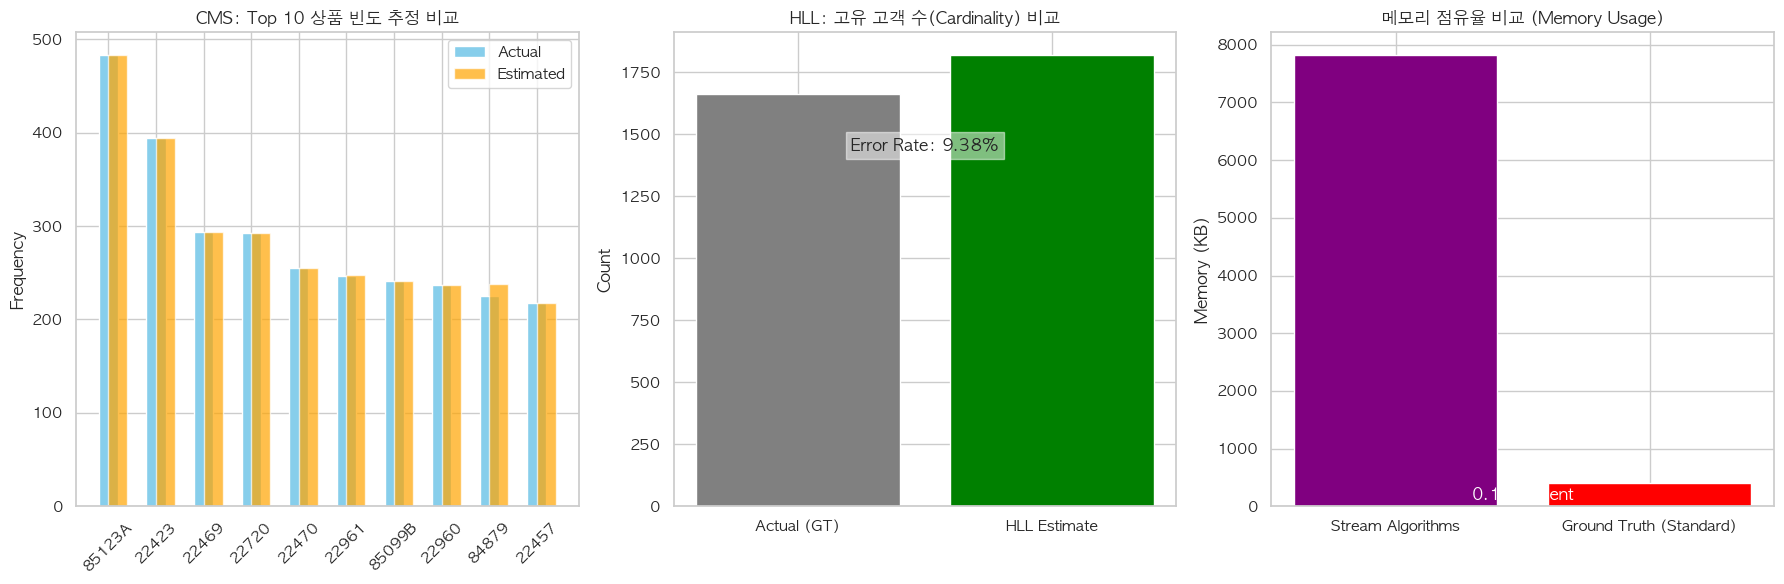

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_results(algo, gt_products, gt_unique_users):
    # 그래프 스타일 설정
    sns.set_theme(style="whitegrid")
    plt.rcParams['font.family'] = 'AppleGothic' # Mac 환경 한글 깨짐 방지
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # (1) Count-Min Sketch: Top 10 상품 빈도 비교 (Actual vs Estimated)
    top_10_items = sorted(gt_products.items(), key=lambda x: x[1], reverse=True)[:10]
    items = [x[0] for x in top_10_items]
    actual_vals = [x[1] for x in top_10_items]
    est_vals = [algo.cms_estimate(item) for item in items]
    
    x = range(len(items))
    axes[0].bar(x, actual_vals, width=0.4, label='Actual', align='center', color='skyblue')
    axes[0].bar(x, est_vals, width=0.4, label='Estimated', align='edge', color='orange', alpha=0.7)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(items, rotation=45)
    axes[0].set_title('CMS: Top 10 상품 빈도 추정 비교')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()

    # (2) HyperLogLog: Cardinality 비교 (Estimate vs Ground Truth)
    hll_val = algo.hll_count()
    gt_val = len(gt_unique_users)
    axes[1].bar(['Actual (GT)', 'HLL Estimate'], [gt_val, hll_val], color=['gray', 'green'])
    axes[1].set_title('HLL: 고유 고객 수(Cardinality) 비교')
    axes[1].set_ylabel('Count')
    # 오차율 텍스트 표시
    error_rate = abs(hll_val - gt_val) / gt_val * 100
    axes[1].text(0.5, max(hll_val, gt_val)*0.8, f'Error Rate: {error_rate:.2f}%', 
                ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

    # (3) Memory Efficiency: Stream vs Ground Truth
    # 자료구조 크기 계산
    mem_stream = (sys.getsizeof(algo.bf_bit_array) + sys.getsizeof(algo.cms_table) + sys.getsizeof(algo.hll_registers)) / 1024
    mem_gt = (sys.getsizeof(gt_customers) + sys.getsizeof(gt_products) + sys.getsizeof(gt_unique_users)) / 1024
    
    axes[2].bar(['Stream Algorithms', 'Ground Truth (Standard)'], [mem_stream, mem_gt], color=['purple', 'red'])
    axes[2].set_title('메모리 점유율 비교 (Memory Usage)')
    axes[2].set_ylabel('Memory (KB)')
    # 효율성 배수 표시
    axes[2].text(0.5, mem_gt*0.5, f'{mem_gt/mem_stream:.1f}x Efficient', 
                ha='center', va='center', fontsize=12, color='white', fontweight='bold')

    plt.tight_layout()
    plt.show()

# 시각화 실행
visualize_results(algo, gt_products, gt_unique_users)

### STEP 05. 파라미터 비교 실험

> 각 알고리즘(Bloom Filter, Count-Min Sketch, HyperLogLog, Reservoir Sampling)의 핵심 파라미터를 변화시키며 오차율과 성능의 상관관계를 분석한다.

가산점 항목: 파라미터 비교 실험 시작...


/var/folders/z3/330pzc_s7s91b8jyfxqhrjxw0000gn/T/ipykernel_73507/230258734.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/iminjae/online_retail/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


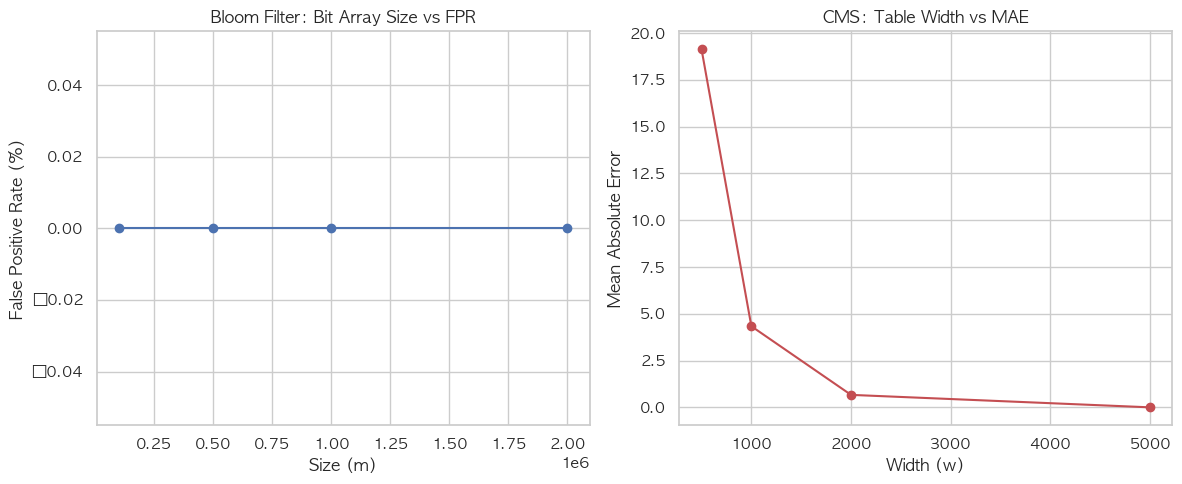

In [7]:
import hashlib
import matplotlib.pyplot as plt

# --- 독립형 클래스 ---

class BloomFilter:
    def __init__(self, m, k):
        self.m = m
        self.k = k
        self.bit_array = [0] * m

    def add(self, item):
        for i in range(self.k):
            idx = int(hashlib.md5((str(item) + str(i)).encode()).hexdigest(), 16) % self.m
            self.bit_array[idx] = 1

    def contains(self, item):
        for i in range(self.k):
            idx = int(hashlib.md5((str(item) + str(i)).encode()).hexdigest(), 16) % self.m
            if self.bit_array[idx] == 0: return False
        return True

class CountMinSketch:
    def __init__(self, width, depth):
        self.width = width
        self.depth = depth
        self.table = [[0] * width for _ in range(depth)]

    def add(self, item):
        for i in range(self.depth):
            idx = int(hashlib.sha1((str(item) + str(i)).encode()).hexdigest(), 16) % self.width
            self.table[i][idx] += 1

    def estimate(self, item):
        return min(self.table[i][int(hashlib.sha1((str(item) + str(i)).encode()).hexdigest(), 16) % self.width] 
                    for i in range(self.depth))

# --- 파라미터 비교 실험 함수 ---

def run_parameter_study():
    print("가산점 항목: 파라미터 비교 실험 시작...")
    
    # 데이터 미리 로드 (상위 50,000개 추출)
    data_list = list(get_data_stream(FILE_PATH, limit=50000))
    
    # (1) Bloom Filter: m(Size) 변화에 따른 FPR
    bf_sizes = [100000, 500000, 1000000, 2000000]
    bf_fprs = []
    for s in bf_sizes:
        test_bf = BloomFilter(m=s, k=5)
        for row in data_list: 
            test_bf.add(str(row['CustomerID'])) # 데이터 타입 에러 방지
        fp = sum(1 for i in range(1000) if test_bf.contains(f"fake_{i}"))
        bf_fprs.append(fp / 10)

    # (2) Count-Min Sketch: Width 변화에 따른 MAE
    cms_widths = [500, 1000, 2000, 5000]
    cms_errors = []
    for w in cms_widths:
        test_cms = CountMinSketch(width=w, depth=5)
        gt_tmp = {}
        for row in data_list:
            sc = str(row['StockCode']) # 데이터 타입 에러 방지
            test_cms.add(sc)
            gt_tmp[sc] = gt_tmp.get(sc, 0) + 1
        mae = sum(abs(test_cms.estimate(p) - gt_tmp[p]) for p in list(gt_tmp.keys())[:500]) / 500
        cms_errors.append(mae)

    # (3) 시각화 (HLL 포함 시 1행 3열로 구성 가능)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(bf_sizes, bf_fprs, 'bo-')
    plt.title('Bloom Filter: Bit Array Size vs FPR')
    plt.xlabel('Size (m)'); plt.ylabel('False Positive Rate (%)')
    
    plt.subplot(1, 2, 2)
    plt.plot(cms_widths, cms_errors, 'ro-')
    plt.title('CMS: Table Width vs MAE')
    plt.xlabel('Width (w)'); plt.ylabel('Mean Absolute Error')
    
    plt.tight_layout()
    plt.show()

# 실행
run_parameter_study()